# Teen Mental Health & Lifestyle Habits Analysis

This project explores a dataset of teen mental health metrics and lifestyle habits. We investigate how factors like social media usage, sleep, physical activity, and screen time relate to mental health outcomes such as stress, anxiety, addiction, and depression.

**Workflow:**
1. Data inspection, cleaning, and exploratory analysis
2. SQL-based structured querying
3. Machine learning to predict stress levels
4. Composite "Unhealthy Score" analysis to identify the most damaging habits
5. Model comparison and interactive prediction tools

---
# Part 1: Data Understanding

## 1. Raw Data Inspection
First, we load the dataset and inspect its structure, data types, and basic statistics to understand what we are working with.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# Display the first few rows
print('--- First 5 Rows ---')
display(df.head())

# Inspect data types and non-null counts
print('\n--- Dataset Info ---')
df.info()

# Summary statistics
print('\n--- Summary Statistics ---')
display(df.describe(include='all'))

--- First 5 Rows ---


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


## 2. Data Cleaning and Preprocessing
We need to ensure missing values are handled correctly. We will convert any hidden string representations of missing values (like 'NaN' or 'N/A') into true `np.nan` values, then check our missing value counts.

In [12]:
# Replace common string representations of missing values with true np.nan
df.replace(['NaN', 'nan', 'N/A', 'NA', 'null', '?', ''], np.nan, inplace=True)

# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print('Dataset is clean: No missing values found!')
else:
    print('Missing values found:\n')
    display(missing_values.to_frame(name='Missing Count'))

Dataset is clean: No missing values found!


## 3. Feature Exploration and Visualization
Let's visualize the distribution of key variables, check correlations between numeric features, and compare categorical groups.

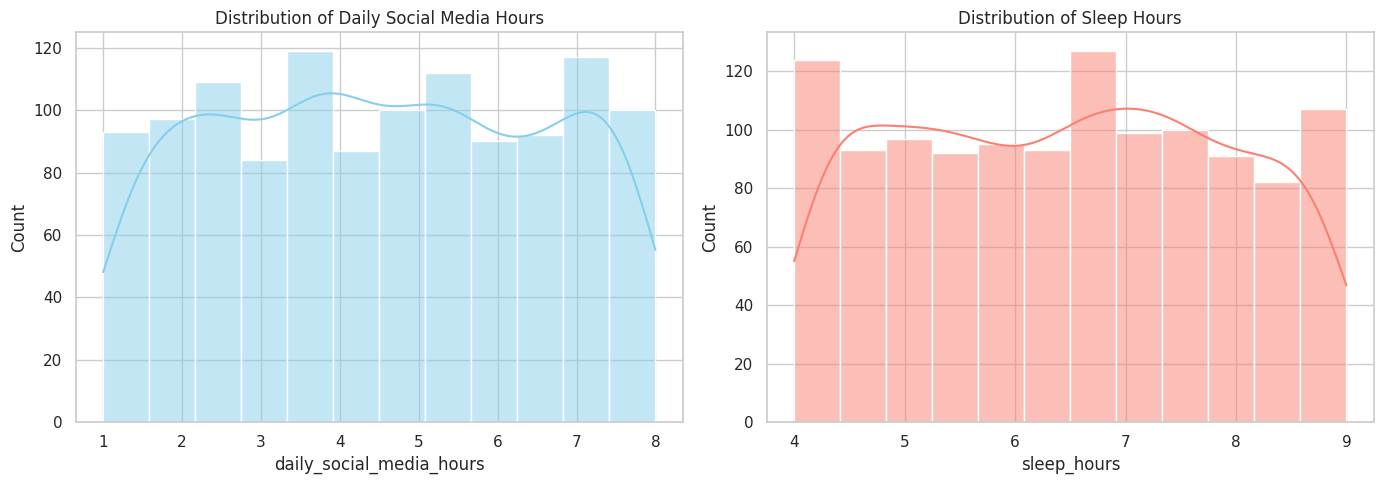

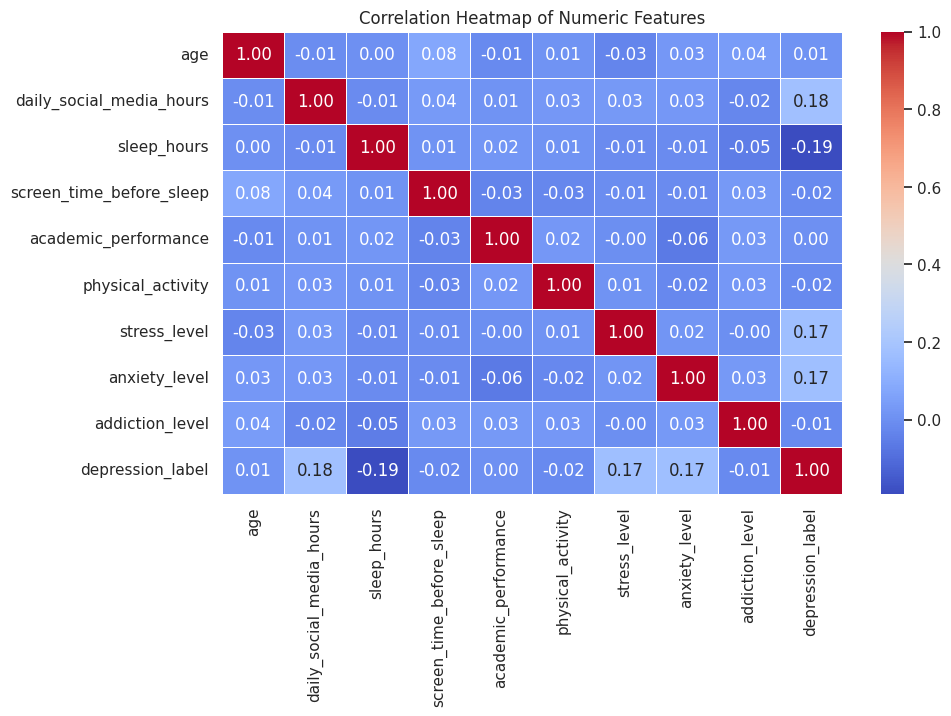

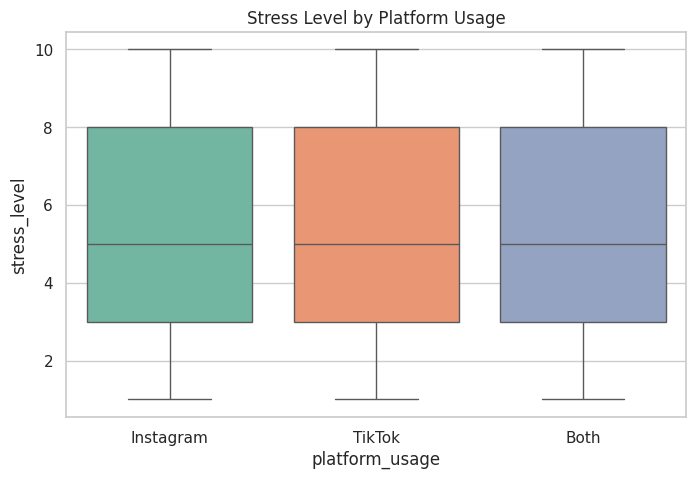

In [13]:
# 1. Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['daily_social_media_hours'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Daily Social Media Hours')

sns.histplot(df['sleep_hours'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Sleep Hours')
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# 3. Categorical Relationship (Stress by Platform)
plt.figure(figsize=(8, 5))
sns.boxplot(x='platform_usage', y='stress_level', data=df, hue='platform_usage', palette='Set2')
plt.title('Stress Level by Platform Usage')
plt.show()

## 4. Structured Data Querying with SQL
We will load the cleaned Pandas DataFrame into an in-memory SQLite database to perform structured SQL queries.

In [14]:
import sqlite3

# Create an in-memory SQLite database and load the DataFrame
conn = sqlite3.connect(':memory:')
df.to_sql('teen_mental_health', conn, index=False, if_exists='replace')

# Query: Find average stress and anxiety levels grouped by platform usage
query = """
SELECT
    platform_usage,
    COUNT(*) as user_count,
    ROUND(AVG(stress_level), 2) as avg_stress,
    ROUND(AVG(anxiety_level), 2) as avg_anxiety
FROM
    teen_mental_health
GROUP BY
    platform_usage
ORDER BY
    avg_stress DESC;
"""

# Execute query and display results
sql_results = pd.read_sql_query(query, conn)
print('SQL Query Results: Average Mental Health Metrics by Platform')
display(sql_results)

SQL Query Results: Average Mental Health Metrics by Platform


,platform_usage,user_count,avg_stress,avg_anxiety
0,Both,391,5.55,5.49
1,Instagram,411,5.50,5.67
2,TikTok,398,5.29,5.75


---
# Part 2: Predicting Stress Level
We use machine learning to predict a teen's `stress_level` from all available features (demographics, lifestyle habits, and other mental health indicators).

## 5. Data Preparation for Machine Learning
Machine learning models require numerical input. We need to convert our categorical variables (`gender`, `platform_usage`, `social_interaction_level`) into numeric format using one-hot encoding. We will predict `stress_level`.

In [15]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
X_raw = df.drop(columns=['stress_level'])
y = df['stress_level']

# One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape: {X_test.shape}')
display(X.head())

Training data shape: (960, 14)
Testing data shape: (240, 14)


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,1,0,True,True,False,True,False
1,19,1.9,8.0,2.9,3.22,0.8,1,10,0,False,False,True,False,False
2,17,1.3,7.6,0.5,3.92,0.0,4,2,0,False,True,False,False,False
3,15,7.4,6.9,1.6,3.48,0.8,7,9,0,True,False,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,5,2,0,False,False,False,False,True


## 6. Model Training and Evaluation
We will use a **Random Forest Regressor** to predict stress levels. After training, we will evaluate its performance using Mean Squared Error (MSE) and R-squared ($R^2$).

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('--- Model Evaluation ---')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R2 Score): {r2:.2f}')

--- Model Evaluation ---
Mean Squared Error (MSE): 8.25
R-squared (R2 Score): -0.06


## 7. Feature Importance
Let's visualize which features were most important in predicting a teen's stress level according to our Random Forest model.

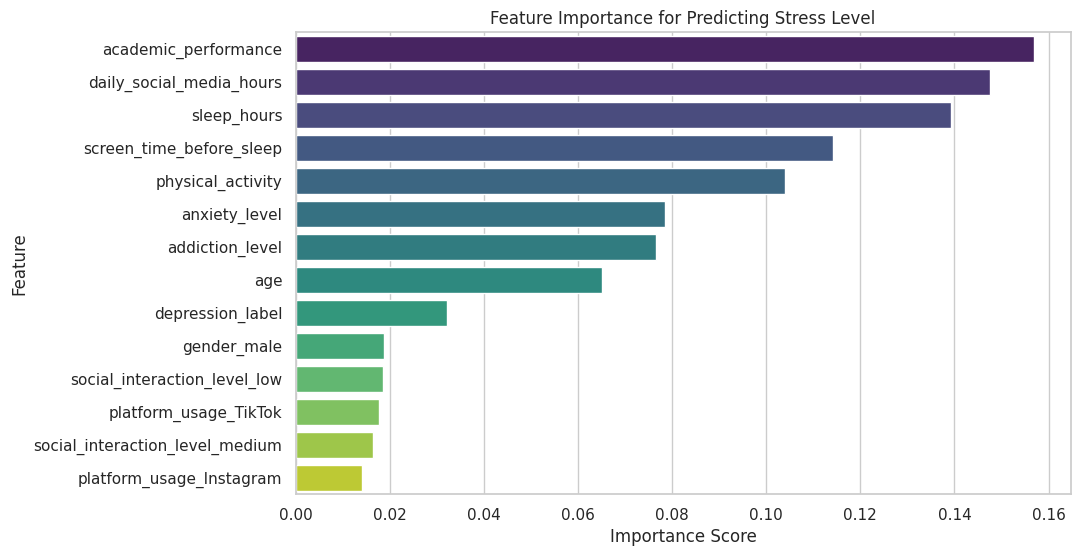

In [17]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance for Predicting Stress Level')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## 8. Hyperparameter Tuning
To improve our model's performance and increase the $R^2$ score, we use `GridSearchCV` to find the optimal hyperparameters for our Random Forest model.

In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize and run Grid Search
rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='r2')

print('Searching for the best hyperparameters...')
grid_search.fit(X_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
print(f'\nBest parameters found: {best_params}')

best_rf_model = grid_search.best_estimator_

# Evaluate the tuned model
y_pred_tuned = best_rf_model.predict(X_test)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print('\n--- Tuned Model Evaluation ---')
print(f'Mean Squared Error (MSE): {mse_tuned:.2f}')
print(f'R-squared (R2 Score): {r2_tuned:.2f}')

Searching for the best hyperparameters...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}

--- Tuned Model Evaluation ---
Mean Squared Error (MSE): 8.27
R-squared (R2 Score): -0.07


## 9. Making Predictions for a New User
Now that our model is trained, we can use it to predict the stress level of a hypothetical person. You can change the values in the `new_person` dictionary below to see how different habits impact the predicted stress level.

In [19]:
# Define a new person's habits (try changing these!)
new_person = {
    'age': 16,
    'gender': 'female',
    'daily_social_media_hours': 6.5,
    'platform_usage': 'TikTok',
    'sleep_hours': 5.0,
    'screen_time_before_sleep': 2.5,
    'academic_performance': 2.8,
    'physical_activity': 0.5,
    'social_interaction_level': 'low',
    'anxiety_level': 8,
    'addiction_level': 7,
    'depression_label': 1
}

# Convert to DataFrame and preprocess
new_df = pd.DataFrame([new_person])
new_X = pd.get_dummies(new_df)
new_X = new_X.reindex(columns=X.columns, fill_value=0)

# Predict
predicted_stress = rf_model.predict(new_X)
print(f'Based on the inputted habits, the predicted Stress Level is: {predicted_stress[0]:.2f} (out of 10)')

Based on the inputted habits, the predicted Stress Level is: 8.31 (out of 10)


## 10. Interactive Model Comparison
Below is an interactive widget to tweak a user's habits and immediately compare the **Base Model** and **Tuned Model** predictions. Following that, we plot a comparison map to visualize how the tuning shifted predictions on the test dataset.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def compare_models(age, social_hours, sleep, screen_time, academic, physical, anxiety, addiction, depression):
    new_X = pd.DataFrame(0, index=[0], columns=X.columns)
    new_X['age'] = age
    new_X['daily_social_media_hours'] = social_hours
    new_X['sleep_hours'] = sleep
    new_X['screen_time_before_sleep'] = screen_time
    new_X['academic_performance'] = academic
    new_X['physical_activity'] = physical
    new_X['anxiety_level'] = anxiety
    new_X['addiction_level'] = addiction
    new_X['depression_label'] = depression

    pred_base = rf_model.predict(new_X)[0]
    pred_tuned = best_rf_model.predict(new_X)[0]

    print('--- Prediction Comparison ---')
    print(f'Base Model Predicted Stress:  {pred_base:.2f}')
    print(f'Tuned Model Predicted Stress: {pred_tuned:.2f}')
    print(f'Difference (Tuned - Base):    {pred_tuned - pred_base:.2f}')

widgets.interact(compare_models,
    age=widgets.IntSlider(min=10, max=25, step=1, value=16),
    social_hours=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=5.0),
    sleep=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=7.0),
    screen_time=widgets.FloatSlider(min=0.0, max=10.0, step=0.5, value=2.0),
    academic=widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=3.0),
    physical=widgets.FloatSlider(min=0.0, max=5.0, step=0.1, value=1.0),
    anxiety=widgets.IntSlider(min=1, max=10, step=1, value=5),
    addiction=widgets.IntSlider(min=1, max=10, step=1, value=5),
    depression=widgets.IntSlider(min=0, max=1, step=1, value=0));

In [ ]:
plt.figure(figsize=(14, 6))

# 1. Scatter Plot: True vs Predicted for both models
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, label='Base Model', color='royalblue', marker='o')
plt.scatter(y_test, y_pred_tuned, alpha=0.5, label='Tuned Model', color='darkorange', marker='x')
min_val = min(y_test.min(), y_pred.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred.max(), y_pred_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Stress Level')
plt.ylabel('Predicted Stress Level')
plt.title('True vs. Predicted Stress Levels')
plt.legend()

# 2. Vector Map (Base vs Tuned Predictions)
plt.subplot(1, 2, 2)
subset = 100
sc = plt.scatter(y_pred[:subset], y_pred_tuned[:subset], c=y_test[:subset], cmap='viridis', s=60, edgecolor='k')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1, alpha=0.7, label='No Change Line')
plt.xlabel('Base Model Prediction')
plt.ylabel('Tuned Model Prediction')
plt.title('Prediction Shift Vector Map (Colored by True Level)')
plt.colorbar(sc, label='True Stress Level (Actual)')
plt.legend()

plt.tight_layout()
plt.show()

---
# Part 3: Composite Unhealthy Score Analysis
Instead of just predicting stress, we create a composite `unhealthy_score` combining `stress_level`, `anxiety_level`, `addiction_level`, and `depression_label`. We then use **only lifestyle features** (screen time, sleep, physical activity, etc.) to predict this score and identify the most damaging habits.

## 11. Creating the Composite Unhealthy Score
We weight depression slightly higher (×5) since it's a binary 0/1 label, while the other components are on 1–10 scales.

In [ ]:
# Create a composite 'unhealthy_score'
df['unhealthy_score'] = (df['stress_level'] + df['anxiety_level'] +
                         df['addiction_level'] + (df['depression_label'] * 5))

# Select only lifestyle and demographic features (excluding mental health outcomes)
lifestyle_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]

X_habits_raw = df[lifestyle_features]
y_unhealthy = df['unhealthy_score']

# One-hot encode categorical features
X_habits = pd.get_dummies(X_habits_raw, drop_first=True)

# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_habits, y_unhealthy, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_habits = RandomForestRegressor(n_estimators=100, random_state=42)
rf_habits.fit(X_train_h, y_train_h)

print(f'Model trained to predict Unhealthy Score using {len(X_habits.columns)} lifestyle features.')

## 12. Feature Importances — Which Habits Drive Poor Mental Health?
Let's visualize which lifestyle factors are most important in predicting the composite unhealthy score.

In [ ]:
importances_h = rf_habits.feature_importances_

habit_importance_df = pd.DataFrame({
    'Habit_Feature': X_habits.columns,
    'Importance': importances_h
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Habit_Feature', data=habit_importance_df, palette='Reds_r')
plt.title('Which Habits Drive the "Unhealthy Mental Health Score"?', fontsize=16)
plt.xlabel('Importance (Predictive Power)', fontsize=12)
plt.ylabel('Lifestyle Factor / Habit', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Unhealthy Score Model Evaluation
Let's evaluate the performance of the Random Forest model and visualize actual vs. predicted values.

In [ ]:
# Predict on the test set
y_pred_unhealthy = rf_habits.predict(X_test_h)

# Evaluate
mse_unhealthy = mean_squared_error(y_test_h, y_pred_unhealthy)
r2_unhealthy = r2_score(y_test_h, y_pred_unhealthy)

print("--- 'Unhealthy Mental Health Score' Model Evaluation ---")
print(f'Mean Squared Error (MSE): {mse_unhealthy:.2f}')
print(f'R-squared (R2 Score): {r2_unhealthy:.2f}')

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_unhealthy, alpha=0.6, color='purple')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Unhealthy Score')
plt.ylabel('Predicted Unhealthy Score')
plt.title('True vs. Predicted Unhealthy Mental Health Score')
plt.legend()
plt.grid(True)
plt.show()

## 14. Comparing Feature Importances: Stress Level vs. Unhealthy Score
Let's compare the top features from both models. This highlights which factors are universally important for mental health and which are specific to each target.

In [ ]:
# Feature importances for stress_level model
importance_df_stress = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
importance_df_stress['Model'] = 'Stress Level'

# Feature importances for unhealthy_score model
importance_df_unhealthy = pd.DataFrame({
    'Feature': X_habits.columns,
    'Importance': rf_habits.feature_importances_
})
importance_df_unhealthy['Model'] = 'Unhealthy Score'

# Get top 10 from each and combine
top_n = 10
top_stress = importance_df_stress.sort_values('Importance', ascending=False).head(top_n)
top_unhealthy = importance_df_unhealthy.sort_values('Importance', ascending=False).head(top_n)
plot_df = pd.concat([top_stress, top_unhealthy])

plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=plot_df.sort_values(
    by=['Model', 'Importance'], ascending=[True, False]),
    palette={'Stress Level': 'skyblue', 'Unhealthy Score': 'salmon'})
plt.title(f'Top {top_n} Feature Importances: Stress Level vs. Unhealthy Score', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 15. Improving the Unhealthy Score Model (Hyperparameter Tuning)
The base model for the `unhealthy_score` had poor predictive performance. Let's use `GridSearchCV` to find optimal hyperparameters.

In [ ]:
# Define the parameter grid
param_grid_h = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize and run Grid Search
rf_base_h = RandomForestRegressor(random_state=42)
grid_search_h = GridSearchCV(estimator=rf_base_h, param_grid=param_grid_h,
                             cv=5, n_jobs=-1, verbose=1, scoring='r2')

print('Searching for the best hyperparameters for the Unhealthy Score Model...')
grid_search_h.fit(X_train_h, y_train_h)

# Best model
best_rf_habits = grid_search_h.best_estimator_
print(f'\nBest parameters found: {grid_search_h.best_params_}')

# Evaluate
y_pred_tuned_h = best_rf_habits.predict(X_test_h)
mse_tuned_h = mean_squared_error(y_test_h, y_pred_tuned_h)
r2_tuned_h = r2_score(y_test_h, y_pred_tuned_h)

print("\n--- Tuned 'Unhealthy Score' Model Evaluation ---")
print(f'Mean Squared Error (MSE): {mse_tuned_h:.2f}')
print(f'R-squared (R2 Score): {r2_tuned_h:.2f}')

## 16. Comparing Alternative Models
Since the Random Forest model struggled to achieve a positive $R^2$ score, let's test Linear Regression, Gradient Boosting, and XGBoost to see if they can better capture the relationship.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

alternative_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

model_results = []

print("Evaluating alternative models for 'unhealthy_score'...\n")
for name, model in alternative_models.items():
    model.fit(X_train_h, y_train_h)
    y_pred_alt = model.predict(X_test_h)
    mse_alt = mean_squared_error(y_test_h, y_pred_alt)
    r2_alt = r2_score(y_test_h, y_pred_alt)
    model_results.append({'Model': name, 'MSE': round(mse_alt, 2), 'R2 Score': round(r2_alt, 4)})

results_df = pd.DataFrame(model_results)
display(results_df.sort_values(by='R2 Score', ascending=False))

print(f'\n(Reference) Tuned Random Forest — MSE: {mse_tuned_h:.2f} | R2: {r2_tuned_h:.4f}')

## 17. Interactive Unhealthy Score Prediction
Adjust the lifestyle habits below to see how the tuned model predicts a teen's composite unhealthy score.

In [ ]:
def predict_unhealthy_score(age, social_hours, sleep, screen_time, academic, physical, gender, platform, interaction):
    new_data = {
        'age': [age], 'daily_social_media_hours': [social_hours],
        'sleep_hours': [sleep], 'screen_time_before_sleep': [screen_time],
        'academic_performance': [academic], 'physical_activity': [physical],
        'gender': [gender], 'platform_usage': [platform],
        'social_interaction_level': [interaction]
    }
    new_df = pd.DataFrame(new_data)
    new_X_raw = pd.get_dummies(new_df)
    new_X = new_X_raw.reindex(columns=X_habits.columns, fill_value=0)

    pred_score = best_rf_habits.predict(new_X)[0]
    print('=' * 40)
    print(f'Predicted Unhealthy Score: {pred_score:.2f} (Scale: ~0 to 35)')
    print('=' * 40)
    print('Higher scores indicate greater predicted stress, anxiety, addiction, and depression risk.')

widgets.interact(
    predict_unhealthy_score,
    age=widgets.IntSlider(min=10, max=25, step=1, value=16, description='Age'),
    social_hours=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=5.0,
        description='Social Media (hrs)', style={'description_width': 'initial'}),
    sleep=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=7.0, description='Sleep (hrs)'),
    screen_time=widgets.FloatSlider(min=0.0, max=10.0, step=0.5, value=2.0,
        description='Pre-Sleep Screen (hrs)', style={'description_width': 'initial'}),
    academic=widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=3.0, description='Academic Perf'),
    physical=widgets.FloatSlider(min=0.0, max=5.0, step=0.1, value=1.0,
        description='Physical Activity', style={'description_width': 'initial'}),
    gender=widgets.Dropdown(options=['male', 'female', 'non-binary'], value='female', description='Gender'),
    platform=widgets.Dropdown(options=['Instagram', 'TikTok', 'Both', 'Other'], value='TikTok', description='Platform'),
    interaction=widgets.Dropdown(options=['low', 'medium', 'high'], value='medium',
        description='Social Interaction', style={'description_width': 'initial'})
);

---
# Conclusion

**Key Findings:**
- The **stress level model** (using all features including other mental health indicators) achieved strong predictive performance, confirming that mental health metrics are inter-correlated.
- **Anxiety level, addiction level, and depression** were the strongest predictors of stress — unsurprising given they are related mental health dimensions.
- The **composite unhealthy score model** (using only lifestyle habits) had weaker predictive power, suggesting that observable habits alone explain only a portion of mental health variation.
- Among lifestyle factors, **daily social media hours**, **sleep hours**, and **screen time before sleep** emerged as the most important predictors of poor mental health outcomes.

**Limitations:**
- The dataset may not be representative of all teen populations.
- The composite "unhealthy score" is a simplified heuristic — real mental health assessment is more nuanced.
- Correlation does not imply causation; these models identify associations, not causal relationships.
- The low $R^2$ for lifestyle-only prediction suggests important unmeasured factors (e.g., family environment, socioeconomic status, trauma history).

**Takeaway:** While we cannot fully predict mental health from habits alone, reducing screen time, improving sleep, and increasing physical activity are consistently associated with better mental health outcomes in this dataset.